# Image Enhancement: Negative Transformation

This notebook introduces **negative transformation**, a simple image enhancement technique. It is a good first example of a **point operation** because each output pixel is computed directly from the value of the corresponding input pixel.

## Learning Objectives

After completing this notebook, students should be able to:

1. Explain the idea of image enhancement.
2. Explain the formula for negative transformation.
3. Read grayscale and color images with OpenCV.
4. Check whether an image file was loaded successfully.
5. Create a negative image using NumPy and OpenCV.
6. Compare vectorized processing with pixel-by-pixel loops.

## 1. Image Enhancement

**Image enhancement** is the process of improving an image so that important visual details become easier to observe or analyze.

Common examples include:

1. Adjusting brightness or contrast.
2. Reducing noise.
3. Sharpening edges.
4. Transforming pixel intensities.

The technique in this notebook works in the **spatial domain**, meaning that it directly changes pixel values in the image. It is also a **point operation**, because each pixel is transformed independently.

## 2. Negative Transformation

For an 8-bit grayscale image, pixel values range from `0` to `255`.

- `0` represents black.
- `255` represents white.

The negative transformation is defined as:

$$
s = (L - 1) - r
$$

where:

- $r$ is the original pixel intensity.
- $s$ is the transformed pixel intensity.
- $L$ is the number of possible intensity levels.

For an 8-bit image, $L = 256$, so the formula becomes:

$$
s = 255 - r
$$

Example:

- If `r = 30`, then `s = 225`.
- If `r = 220`, then `s = 35`.

## 3. Import Libraries and Define Helper Functions

OpenCV returns `None` when `cv2.imread()` cannot load an image. This commonly happens when the file path is incorrect or the file does not exist.

Therefore, every image-loading step should check whether the returned image is `None`.

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = Path("images")
OUT_DIR = Path("outs")
OUT_DIR.mkdir(exist_ok=True)


def read_image(fp, flags=cv2.IMREAD_COLOR):
    img = cv2.imread(str(fp), flags)

    if img is None:
        raise FileNotFoundError(f"Image file not found: {fp}")

    return img


def show_gray_pair(original, transformed, title1="Original", title2="Negative"):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(original, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title(title1)
    axes[0].axis("off")

    axes[1].imshow(transformed, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title(title2)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


def show_color_pair(original_bgr, transformed_bgr, title1="Original", title2="Negative"):
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    transformed_rgb = cv2.cvtColor(transformed_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    axes[0].imshow(original_rgb)
    axes[0].set_title(title1)
    axes[0].axis("off")

    axes[1].imshow(transformed_rgb)
    axes[1].set_title(title2)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

## 4. Read a Grayscale Image

The image `cortex.png` is used as the grayscale example. The image is loaded with `cv2.IMREAD_GRAYSCALE`, so the result is a 2D NumPy array.

type: <class 'numpy.ndarray'>
shape: (443, 443)
dtype: uint8
min, max: 0 255


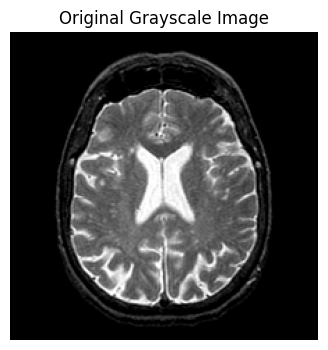

In [2]:
fp = IMAGE_DIR / "cortex.png"
img = read_image(fp, cv2.IMREAD_GRAYSCALE)

print("type:", type(img))
print("shape:", img.shape)
print("dtype:", img.dtype)
print("min, max:", img.min(), img.max())

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

## 5. Method I: Vectorized NumPy Operation

This is the recommended method for practical use. NumPy applies the formula to the whole image at once, so the code is short, clear, and efficient.

original shape: (443, 443)
negative shape: (443, 443)
dtype: uint8


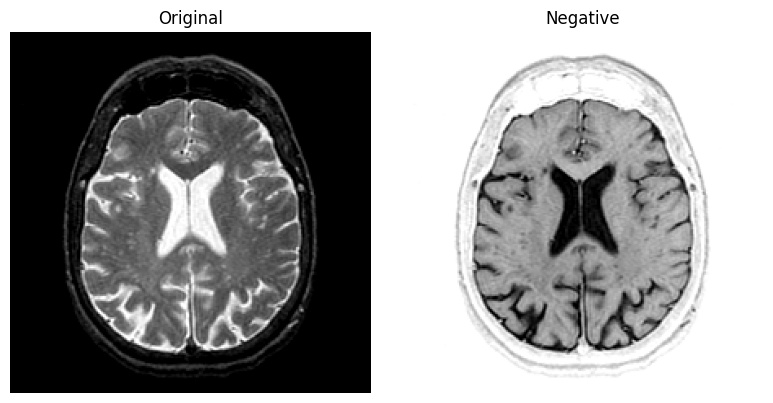

In [3]:
neg_vector = 255 - img

print("original shape:", img.shape)
print("negative shape:", neg_vector.shape)
print("dtype:", neg_vector.dtype)

show_gray_pair(img, neg_vector)

## 6. Save the Output Image

`cv2.imwrite()` returns `True` if the image was saved successfully. It is good practice to check this value.

In [4]:
out_fp = OUT_DIR / "cortex_negative.png"
saved = cv2.imwrite(str(out_fp), neg_vector)

if not saved:
    raise IOError(f"Could not save image: {out_fp}")

print(f"Saved image: {out_fp}")

Saved image: outs\cortex_negative.png


## 7. Method II: Pixel-by-Pixel Loop

This method is useful for teaching because it shows the operation at each pixel position. However, it is slower and longer than the vectorized NumPy method.

Loop result equals vectorized result: True


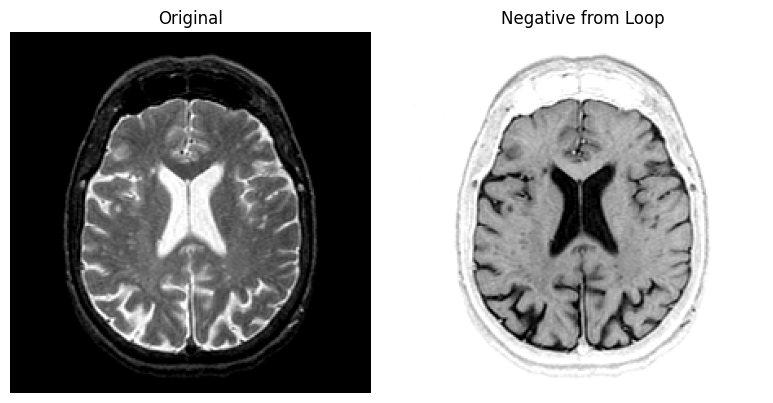

In [5]:
neg_loop = np.zeros_like(img, dtype=np.uint8)
rows, cols = img.shape

for y in range(rows):
    for x in range(cols):
        neg_loop[y, x] = 255 - img[y, x]

print("Loop result equals vectorized result:", np.array_equal(neg_loop, neg_vector))
show_gray_pair(img, neg_loop, title2="Negative from Loop")

## 8. Method III: OpenCV Function

OpenCV provides `cv2.bitwise_not()`. For an 8-bit image, it produces the same result as `255 - img`.

OpenCV result equals vectorized result: True


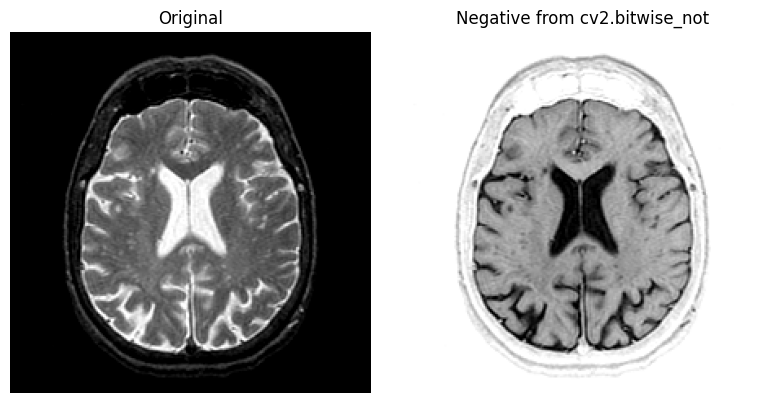

In [6]:
neg_cv = cv2.bitwise_not(img)

print("OpenCV result equals vectorized result:", np.array_equal(neg_cv, neg_vector))
show_gray_pair(img, neg_cv, title2="Negative from cv2.bitwise_not")

## 9. Inspect Pixel Values

The transformation changes the intensity value of each pixel, but the pixel location stays the same.

In [7]:
sample_points = [
    (0, 0),
    (img.shape[0] // 2, img.shape[1] // 2),
    (img.shape[0] - 1, img.shape[1] - 1),
]

for y, x in sample_points:
    original_value = img[y, x]
    negative_value = neg_vector[y, x]
    print(f"Position ({y:3d}, {x:3d}) : {original_value:3d} -> {negative_value:3d}")

Position (  0,   0) :   0 -> 255
Position (221, 221) : 226 ->  29
Position (442, 442) :   0 -> 255


## 10. Negative Transformation for a Color Image

For a color image, the same transformation is applied to each channel.

If a pixel has RGB values $(R, G, B)$, the negative pixel is:

$$
(255 - R,\ 255 - G,\ 255 - B)
$$

OpenCV reads color images in **BGR** order, not RGB. Therefore, the image must be converted from BGR to RGB before displaying it with Matplotlib.

shape: (512, 512, 3)
dtype: uint8


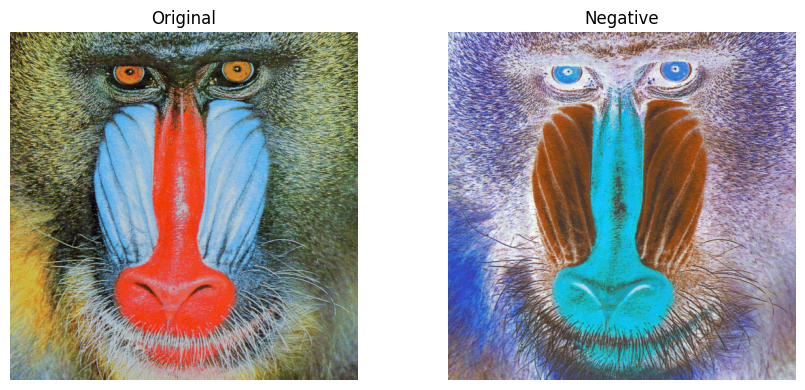

In [8]:
fp = IMAGE_DIR / "mandril_color.tif"
color_img = read_image(fp, cv2.IMREAD_COLOR)

print("shape:", color_img.shape)
print("dtype:", color_img.dtype)

color_negative = 255 - color_img
show_color_pair(color_img, color_negative)

## 11. Channel-by-Channel Processing

A color image loaded by OpenCV has three channels: Blue, Green, and Red. The negative transformation can be applied to each channel separately and then merged back into one image.

Channel result equals direct color result: True


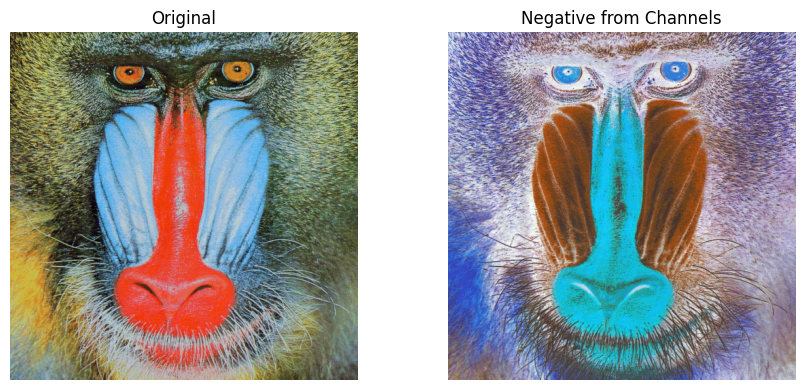

In [9]:
b, g, r = cv2.split(color_img)

b_neg = 255 - b
g_neg = 255 - g
r_neg = 255 - r

color_negative_from_channels = cv2.merge((b_neg, g_neg, r_neg))

print(
    "Channel result equals direct color result:",
    np.array_equal(color_negative_from_channels, color_negative),
)

show_color_pair(color_img, color_negative_from_channels, title2="Negative from Channels")

## 12. Summary

The negative transformation for an 8-bit image is:

$$
s = 255 - r
$$

Key points:

1. Dark pixels become bright.
2. Bright pixels become dark.
3. The operation is a point operation.
4. `255 - img` is simple and efficient for NumPy arrays.
5. `cv2.bitwise_not(img)` gives the same result for 8-bit images.
6. Always check whether `cv2.imread()` returns `None`.

## Review Questions

1. If the original pixel value is `10`, what is the negative value?
2. If the original pixel value is `200`, what is the negative value?
3. Why is the vectorized NumPy method usually better than a pixel-by-pixel loop?